# Practice 16 — CNN 기초 (Convolutional Neural Network)

Lec 08 강의 내용을 기반으로 **합성곱 신경망**을 구현합니다.

이전까지 모든 데이터(Iris, Digits, AI4I)를 1D 벡터로 다뤘습니다.
이번에는 **2D 이미지** (MNIST 손글씨)를 그대로 다루는 CNN을 구현합니다.

| # | 내용 |
|---|------|
| 1 | MLP의 한계 — 이미지를 평탄화하면? |
| 2 | Convolution 연산 직관 |
| 3 | Pooling |
| 4 | CNN 모델 정의 (Class + nn.Module) |
| 5 | MNIST 데이터 파이프라인 |
| 6 | 학습 |
| 7 | MLP vs CNN 비교 |
| 8 | (보너스) nn.Sequential 로 다시 쓰기 |
| 9 | (도전) 전체 MNIST + 더 많은 epoch — ~99% 도달 |


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)


torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


---
# 1. MLP의 한계 — 이미지를 평탄화하면?

지금까지 모든 데이터는 **1D 벡터**였습니다. (Iris 4차원, Digits 64차원, ...)

이미지는 2D 구조를 갖지만, MLP에 넣으려면 **평탄화(flatten)** 가 필요합니다.

> **문제 1:** 평탄화하면 *어떤 픽셀이 어떤 픽셀과 가까운지* 정보가 사라집니다.
>
> **문제 2:** 1픽셀만 옆으로 옮겨도 입력 벡터가 **완전히 달라집니다**.


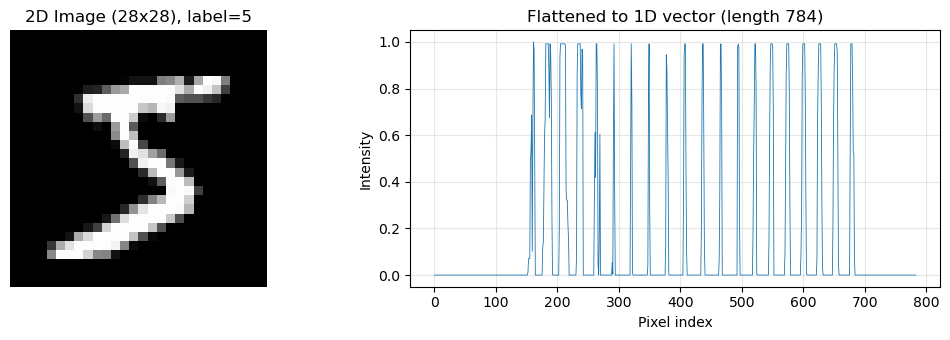

2D shape: (28, 28)  ->  Flattened: (784,)
-> 평탄화하면 인접 픽셀(2D 이웃)이 멀어집니다.


In [2]:
# MNIST 샘플 1장 불러오기 (다운로드는 첫 실행 시에만)
mnist_sample = torchvision.datasets.MNIST(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor())
img, label = mnist_sample[0]   # img: (1, 28, 28), label: int

img_2d = img.squeeze().numpy()         # (28, 28)
img_1d = img_2d.flatten()              # (784,)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].imshow(img_2d, cmap='gray')
axes[0].set_title(f'2D Image (28x28), label={label}')
axes[0].axis('off')
axes[1].plot(img_1d, linewidth=0.6)
axes[1].set_title('Flattened to 1D vector (length 784)')
axes[1].set_xlabel('Pixel index'); axes[1].set_ylabel('Intensity')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'2D shape: {img_2d.shape}  ->  Flattened: {img_1d.shape}')
print('-> 평탄화하면 인접 픽셀(2D 이웃)이 멀어집니다.')


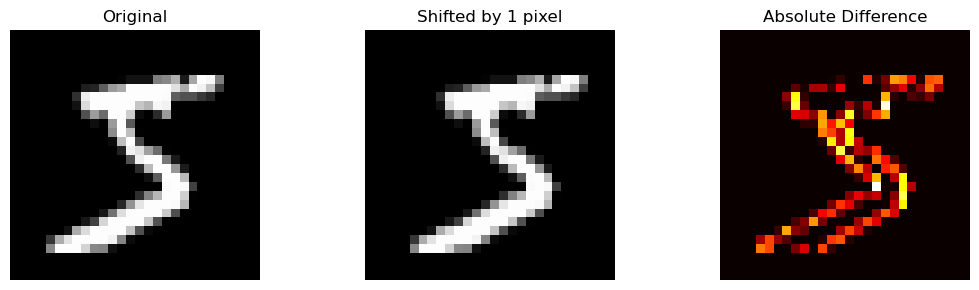

바뀐 픽셀 수: 149 / 784
벡터 거리(L1): 43.62
-> 사람 눈에는 "같은 숫자"지만, MLP에는 거의 다른 입력으로 보입니다.


In [3]:
# 1픽셀 시프트 효과 — 같은 이미지인데 입력 벡터가 얼마나 달라지는가?
img_orig = img_2d.copy()
img_shift = np.roll(img_orig, shift=1, axis=1)   # 오른쪽으로 1픽셀 이동

# 두 벡터의 차이
diff = np.abs(img_orig.flatten() - img_shift.flatten())

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].imshow(img_orig, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(img_shift, cmap='gray'); axes[1].set_title('Shifted by 1 pixel')
axes[2].imshow(np.abs(img_orig - img_shift), cmap='hot')
axes[2].set_title('Absolute Difference')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f'바뀐 픽셀 수: {(diff > 0).sum()} / 784')
print(f'벡터 거리(L1): {diff.sum():.2f}')
print('-> 사람 눈에는 "같은 숫자"지만, MLP에는 거의 다른 입력으로 보입니다.')


---
# 2. Convolution 연산 직관

**핵심 아이디어:** 작은 필터(커널, 보통 3x3)를 이미지 위에서 슬라이딩하며 같은 가중치로 곱하기-합산.

$$y[i,j] = \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} x[i+m,\,j+n]\,\cdot\,w[m,n]$$

- 같은 커널이 모든 위치에 적용 → **가중치 공유 (weight sharing)**
- 평탄화 안 함 → **2D 구조 유지**
- 1픽셀 시프트해도 출력도 1픽셀 시프트만 됨 → **위치 변화에 강건**


In [4]:
# 수동 합성곱: 3x3 수직 엣지 검출 커널
kernel_np = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)

H, W = img_2d.shape         # 28, 28
out_h, out_w = H - 2, W - 2 # padding=0, stride=1, K=3 -> 26x26

out_manual = np.zeros((out_h, out_w), dtype=np.float32)
for i in range(out_h):
    for j in range(out_w):
        # 3x3 영역과 커널의 element-wise 곱의 합
        out_manual[i, j] = (img_2d[i:i+3, j:j+3] * kernel_np).sum()

print(f'Input:  {img_2d.shape}')
print(f'Kernel: {kernel_np.shape}')
print(f'Output: {out_manual.shape}  (= H-K+1, W-K+1)')


Input:  (28, 28)
Kernel: (3, 3)
Output: (26, 26)  (= H-K+1, W-K+1)


Manual vs torch match: True


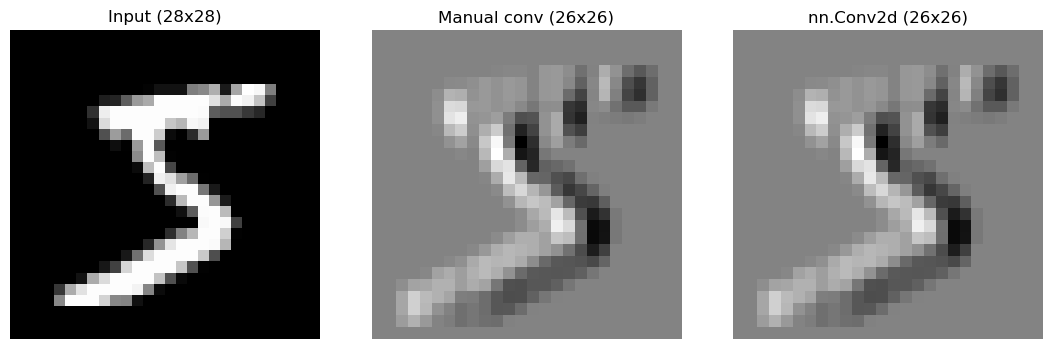

-> 수직 엣지(세로 윤곽)가 강하게 검출됩니다.


In [5]:
# nn.Conv2d로 같은 연산 — 결과가 같은지 확인
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)
# 학습 대신 우리가 정의한 커널을 직접 weight에 넣음
with torch.no_grad():
    conv.weight.copy_(torch.tensor(kernel_np).reshape(1, 1, 3, 3))

# nn.Conv2d 입력 shape 규약: (N, C, H, W)
img_t = torch.tensor(img_2d).unsqueeze(0).unsqueeze(0)   # (1, 1, 28, 28)
out_torch = conv(img_t).squeeze().detach().numpy()       # (26, 26)

# 두 결과 비교
match = np.allclose(out_manual, out_torch, atol=1e-5)
print(f'Manual vs torch match: {match}')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(img_2d, cmap='gray'); axes[0].set_title('Input (28x28)')
axes[1].imshow(out_manual, cmap='gray'); axes[1].set_title('Manual conv (26x26)')
axes[2].imshow(out_torch, cmap='gray'); axes[2].set_title('nn.Conv2d (26x26)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print('-> 수직 엣지(세로 윤곽)가 강하게 검출됩니다.')


## 출력 shape 공식

$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2P - K}{S} \right\rfloor + 1$$

| 인자 | 의미 |
|------|------|
| $K$ | kernel size |
| $P$ | padding (가장자리 0 추가) |
| $S$ | stride (커널 이동 폭) |

**자주 쓰는 조합:**
- $K=3,\,P=1,\,S=1$ → 출력 크기 **유지** (28→28)
- $K=3,\,P=0,\,S=1$ → 2씩 줄어듦 (28→26)
- $K=2,\,P=0,\,S=2$ (MaxPool) → **절반** (28→14)


In [6]:
# 같은 입력에 padding=1을 주면 출력 크기가 유지됨
conv_no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0, bias=False)
conv_pad    = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

x = torch.randn(1, 1, 28, 28)
print(f'Input:                 {tuple(x.shape)}')
print(f'Conv2d(K=3, P=0):      {tuple(conv_no_pad(x).shape)}   <- 줄어듦')
print(f'Conv2d(K=3, P=1):      {tuple(conv_pad(x).shape)}   <- 유지')


Input:                 (1, 1, 28, 28)
Conv2d(K=3, P=0):      (1, 1, 26, 26)   <- 줄어듦
Conv2d(K=3, P=1):      (1, 1, 28, 28)   <- 유지


---
# 3. Pooling — 다운샘플링

**MaxPool**: 영역 내 **최댓값** (가장 강한 활성)을 골라 해상도를 줄입니다.

- 학습 파라미터 없음
- 작은 위치 변화에 강건
- 연산량 감소


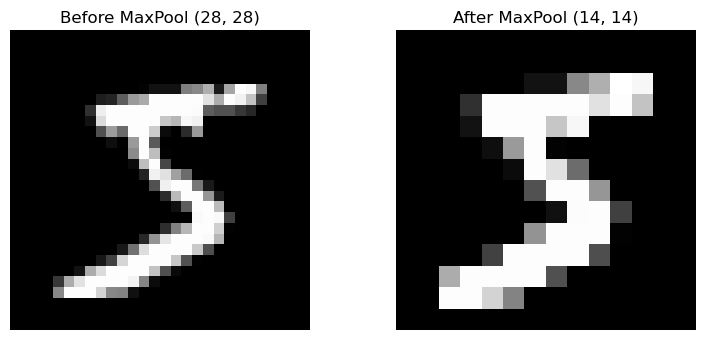

Shape: (1, 1, 28, 28) -> (1, 1, 14, 14)


In [7]:
# MaxPool2d(2): 2x2 영역의 최댓값 -> 해상도 절반
pool = nn.MaxPool2d(kernel_size=2, stride=2)

img_t_4d = torch.tensor(img_2d).unsqueeze(0).unsqueeze(0)   # (1, 1, 28, 28)
pooled = pool(img_t_4d).squeeze().numpy()                   # (14, 14)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(img_2d, cmap='gray'); axes[0].set_title(f'Before MaxPool {img_2d.shape}')
axes[1].imshow(pooled, cmap='gray'); axes[1].set_title(f'After MaxPool {pooled.shape}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f'Shape: {tuple(img_t_4d.shape)} -> {tuple(pool(img_t_4d).shape)}')


---
# 4. CNN 모델 정의

**구조:** 두 개의 `[Conv → ReLU → MaxPool]` 블록 + 마지막 FC

```
Input        (N, 1, 28, 28)
  layer1: Conv2d(1->32, k=3, p=1) -> ReLU -> MaxPool(2)   -> (N, 32, 14, 14)
  layer2: Conv2d(32->64, k=3, p=1) -> ReLU -> MaxPool(2)  -> (N, 64,  7,  7)
  flatten                                                  -> (N, 64*7*7)
  fc:     Linear(64*7*7, 10)                              -> (N, 10)
```

P10에서 본 `class ... nn.Module` 패턴을 확장해, **블록 단위로 self.layer1, self.layer2** 처럼 분리합니다. forward도 명시적으로 작성합니다.


In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력: (N, 1, 28, 28)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (N, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2)                                # (N, 32, 14, 14)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (N, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2)                                # (N, 64,  7,  7)
        )
        self.fc = nn.Linear(64 * 7 * 7, 10)               # (N, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.flatten(1)        # (N, 64*7*7) - 배치 차원 제외하고 평탄화
        x = self.fc(x)
        return x

torch.manual_seed(42)
model = CNN()
print(model)


CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)


In [9]:
# 각 단계의 출력 shape 확인 (dummy 입력으로)
dummy = torch.randn(2, 1, 28, 28)   # batch=2
print(f'Input         : {tuple(dummy.shape)}')

x = model.layer1(dummy)
print(f'After layer1  : {tuple(x.shape)}')
x = model.layer2(x)
print(f'After layer2  : {tuple(x.shape)}')
x = x.flatten(1)
print(f'After flatten : {tuple(x.shape)}')
x = model.fc(x)
print(f'Output (logits): {tuple(x.shape)}')

n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')


Input         : (2, 1, 28, 28)
After layer1  : (2, 32, 14, 14)
After layer2  : (2, 64, 7, 7)
After flatten : (2, 3136)
Output (logits): (2, 10)

Total parameters: 50,186


---
# 5. MNIST 데이터 파이프라인

**MNIST**: 28x28 손글씨 숫자 (0~9) 70,000장. 이미지 분류의 "Hello World".

CPU 실행을 빠르게 하기 위해 **부분집합 (train 10000 / test 2000)** 으로 학습합니다.
(섹션 9의 도전 과제에서 전체 데이터로 다시 학습합니다.)


In [10]:
# transforms.ToTensor(): PIL Image -> FloatTensor (C, H, W), 값 0~1로 스케일
transform = transforms.ToTensor()

train_full = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# CPU 친화적 부분집합
train_set = Subset(train_full, indices=list(range(10000)))
test_set  = Subset(test_full,  indices=list(range(2000)))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

print(f'Train: {len(train_set)} samples (full: {len(train_full)})')
print(f'Test : {len(test_set)} samples (full: {len(test_full)})')

# 한 배치 가져와서 shape 확인
X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape: {tuple(X_batch.shape)}  (N, C, H, W)')
print(f'Batch y shape: {tuple(y_batch.shape)}')


Train: 10000 samples (full: 60000)
Test : 2000 samples (full: 10000)


Batch X shape: (128, 1, 28, 28)  (N, C, H, W)
Batch y shape: (128,)


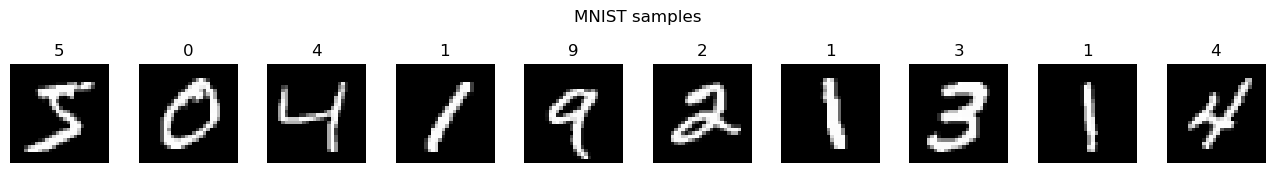

In [11]:
# 샘플 10장 시각화
fig, axes = plt.subplots(1, 10, figsize=(13, 1.6))
for i in range(10):
    img_i, label_i = train_set[i]
    axes[i].imshow(img_i.squeeze(), cmap='gray')
    axes[i].set_title(f'{label_i}')
    axes[i].axis('off')
plt.suptitle('MNIST samples', y=1.05)
plt.tight_layout(); plt.show()


---
# 6. 학습

P11~P13에서 사용한 **train 함수를 그대로** 사용합니다. CNN도 결국 `nn.Module`이라 같은 학습 루프가 동작합니다.


In [12]:
# 모델을 학습하고 epoch별 (train_loss, test_loss, test_acc) 리스트를 반환
def train(model, train_loader, test_loader, optimizer, epochs=3):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []

    for epoch in range(epochs):
        # 훈련
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_losses.append(loss_sum / count)

        # 평가
        model.eval()
        loss_sum, correct, count = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, Y_batch in test_loader:
                output = model(X_batch)
                loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
                correct += (output.argmax(1) == Y_batch).sum().item()
                count += len(Y_batch)
        test_losses.append(loss_sum / count)
        test_accs.append(correct / count)

        print(f'  Epoch {epoch+1}/{epochs}  '
              f'train_loss={train_losses[-1]:.4f}  '
              f'test_loss={test_losses[-1]:.4f}  '
              f'test_acc={test_accs[-1]:.4f}')

    return train_losses, test_losses, test_accs


In [13]:
# CNN 학습
torch.manual_seed(42)
model_cnn = CNN()
opt_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

print('Training CNN...')
tl_cnn, vl_cnn, va_cnn = train(model_cnn, train_loader, test_loader, opt_cnn, epochs=3)
print(f'\nFinal test accuracy: {va_cnn[-1]:.4f}')


Training CNN...


  Epoch 1/3  train_loss=0.8780  test_loss=0.3889  test_acc=0.8805


  Epoch 2/3  train_loss=0.2472  test_loss=0.2355  test_acc=0.9295


  Epoch 3/3  train_loss=0.1583  test_loss=0.1687  test_acc=0.9490

Final test accuracy: 0.9490


---
# 7. 비교 실험: MLP vs CNN

같은 데이터에 두 모델을 학습시켜 봅니다.

- **MLP**: 입력을 평탄화 (784) → Linear → ReLU → Linear → ReLU → Linear (10)
- **CNN**: 위에서 정의한 2-layer CNN

공정한 비교를 위해 **같은 옵티마이저(Adam, lr=1e-3), 같은 epoch**, `torch.manual_seed(42)` 재설정 후 학습합니다.


In [14]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력: (N, 1, 28, 28) -> flatten -> (N, 784)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)   # (N, 784)
        x = self.fc(x)        # (N, 10)
        return x

torch.manual_seed(42)
model_mlp = MLP()
print(model_mlp)
print(f'\nMLP parameters: {sum(p.numel() for p in model_mlp.parameters()):,}')
print(f'CNN parameters: {sum(p.numel() for p in model_cnn.parameters()):,}')


MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

MLP parameters: 109,386
CNN parameters: 50,186


In [15]:
# MLP 학습 (CNN과 동일한 조건)
torch.manual_seed(42)
model_mlp = MLP()
opt_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

print('Training MLP...')
tl_mlp, vl_mlp, va_mlp = train(model_mlp, train_loader, test_loader, opt_mlp, epochs=3)
print(f'\nFinal test accuracy: {va_mlp[-1]:.4f}')


Training MLP...


  Epoch 1/3  train_loss=1.0324  test_loss=0.5175  test_acc=0.8525


  Epoch 2/3  train_loss=0.3554  test_loss=0.4060  test_acc=0.8790


  Epoch 3/3  train_loss=0.2931  test_loss=0.3767  test_acc=0.8920

Final test accuracy: 0.8920


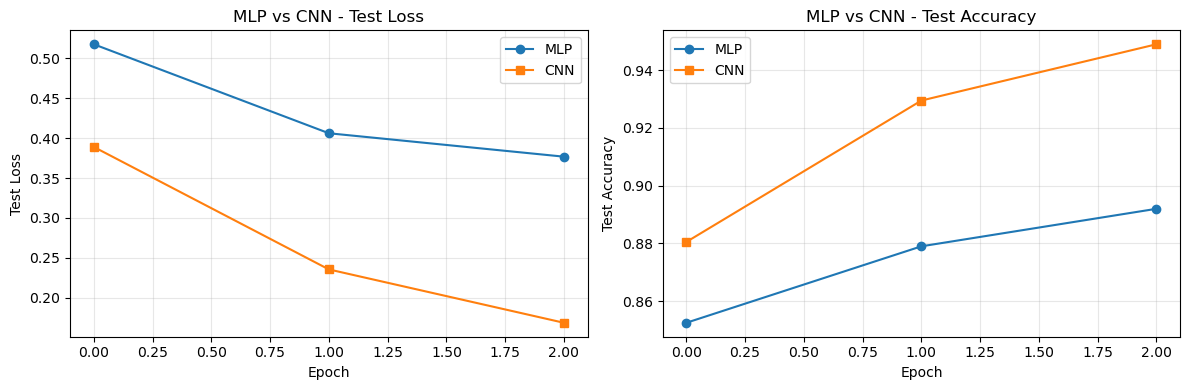

MLP final accuracy: 0.8920
CNN final accuracy: 0.9490


In [16]:
# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vl_mlp, 'o-', label='MLP')
axes[0].plot(vl_cnn, 's-', label='CNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('MLP vs CNN - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(va_mlp, 'o-', label='MLP')
axes[1].plot(va_cnn, 's-', label='CNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('MLP vs CNN - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'MLP final accuracy: {va_mlp[-1]:.4f}')
print(f'CNN final accuracy: {va_cnn[-1]:.4f}')


## 정리

| 구분 | MLP | CNN |
|------|-----|-----|
| 입력 처리 | 평탄화 (784,) | 2D 그대로 (1, 28, 28) |
| 가중치 공유 | 없음 (모든 위치 독립) | **있음** (같은 커널이 슬라이딩) |
| 위치 변화 | 약함 | 강건함 |
| 파라미터 수 | 적당히 큼 | (FC 뺀 conv 부분은) 적음 |
| 같은 epoch | 보통 | **더 좋음** |

CNN이 이미지에 강한 이유는 **2D 구조 보존**과 **가중치 공유** 두 가지입니다.


---
# 8. (보너스) nn.Sequential 로 다시 쓰기

P12, P13에서 사용한 `nn.Sequential` 만으로도 같은 CNN을 정의할 수 있습니다.

**언제 어떤 스타일?**
- `nn.Sequential` 한 줄 정의: 단순 모델, 빠른 프로토타이핑
- `class ... nn.Module`: 블록 분리·forward 커스터마이즈가 필요할 때 (대부분의 실전 모델)

아래 두 정의는 **수학적으로 완전히 동일**합니다.


In [17]:
# 같은 CNN을 nn.Sequential 로 작성
torch.manual_seed(42)
model_seq = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),                  # nn.Module 버전의 .flatten(1) 과 동일
    nn.Linear(64 * 7 * 7, 10)
)

# class 버전과 출력 shape 비교
torch.manual_seed(42)
model_class = CNN()

dummy = torch.randn(2, 1, 28, 28)
out_seq   = model_seq(dummy)
out_class = model_class(dummy)

print(f'Sequential output shape: {tuple(out_seq.shape)}')
print(f'Class       output shape: {tuple(out_class.shape)}')
print(f'Parameter count match: '
      f'{sum(p.numel() for p in model_seq.parameters()) == sum(p.numel() for p in model_class.parameters())}')


Sequential output shape: (2, 10)
Class       output shape: (2, 10)
Parameter count match: True


---
# 9. (도전) 전체 MNIST + 더 많은 epoch — 어디까지 갈 수 있나?

지금까지는 빠른 학습을 위해 **부분집합 (10000장)** 만 사용했습니다.

이번엔 **전체 60000장 + 8 epoch** 으로 학습하면 어디까지 가는지 봅니다.
참고로 레퍼런스 구현(15 epoch, full data, batch=100, lr=0.001)에서는 **약 99% 정확도**가 나옵니다.

> CPU 기준 약 3~5분 소요. GPU(CUDA) 사용 시 30초 이내.
> 시간이 부족하면 이 셀은 건너뛰어도 됩니다.


In [18]:
# 전체 MNIST 데이터 로더 (batch_size 키워서 속도 개선)
train_loader_full = DataLoader(train_full, batch_size=256, shuffle=True)
test_loader_full  = DataLoader(test_full,  batch_size=512, shuffle=False)

print(f'Train: {len(train_full)} samples')
print(f'Test : {len(test_full)} samples')

# 새 CNN 모델 (위와 동일 구조)
torch.manual_seed(42)
model_full = CNN()
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)

import time
print('\nTraining on full MNIST (8 epochs)...')
t0 = time.time()
tl_full, vl_full, va_full = train(model_full, train_loader_full, test_loader_full,
                                  opt_full, epochs=8)
elapsed = time.time() - t0
print(f'\nElapsed: {elapsed:.1f}s')
print(f'Final test accuracy: {va_full[-1]:.4f}  (peak: {max(va_full):.4f})')


Train: 60000 samples
Test : 10000 samples

Training on full MNIST (8 epochs)...


  Epoch 1/8  train_loss=0.3851  test_loss=0.1011  test_acc=0.9715


  Epoch 2/8  train_loss=0.0847  test_loss=0.0558  test_acc=0.9835


  Epoch 3/8  train_loss=0.0584  test_loss=0.0463  test_acc=0.9849


  Epoch 4/8  train_loss=0.0464  test_loss=0.0401  test_acc=0.9865


  Epoch 5/8  train_loss=0.0395  test_loss=0.0359  test_acc=0.9884


  Epoch 6/8  train_loss=0.0349  test_loss=0.0339  test_acc=0.9881


  Epoch 7/8  train_loss=0.0307  test_loss=0.0346  test_acc=0.9876


  Epoch 8/8  train_loss=0.0271  test_loss=0.0323  test_acc=0.9891

Elapsed: 63.8s
Final test accuracy: 0.9891  (peak: 0.9891)


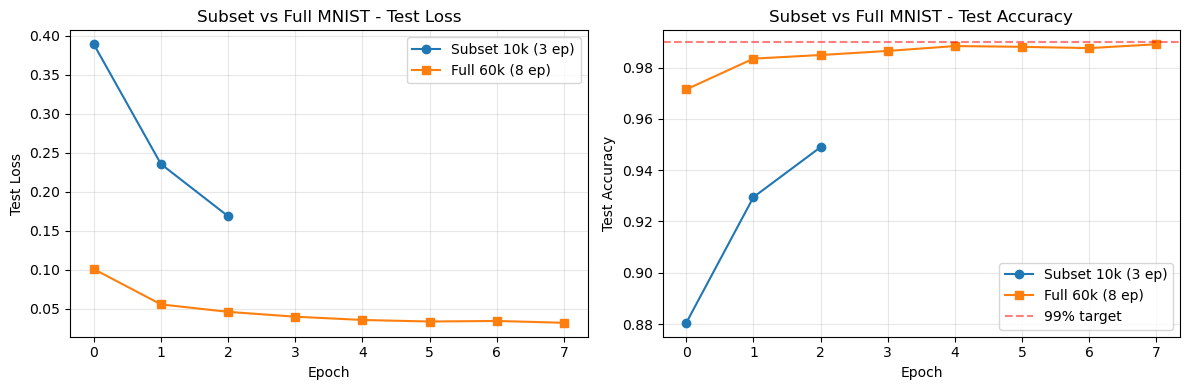

Subset (3 ep) final: 0.9490
Full   (8 ep) final: 0.9891


In [19]:
# 부분집합 vs 전체 데이터 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vl_cnn, 'o-', label=f'Subset 10k (3 ep)')
axes[0].plot(vl_full, 's-', label=f'Full 60k (8 ep)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Subset vs Full MNIST - Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(va_cnn, 'o-', label=f'Subset 10k (3 ep)')
axes[1].plot(va_full, 's-', label=f'Full 60k (8 ep)')
axes[1].axhline(0.99, ls='--', color='red', alpha=0.5, label='99% target')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Subset vs Full MNIST - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Subset (3 ep) final: {va_cnn[-1]:.4f}')
print(f'Full   (8 ep) final: {va_full[-1]:.4f}')


---
### 연습 문제

1. CNN 모델의 `Conv2d(1, 32, ...)` 의 `32`(출력 채널 수)를 16, 64로 바꾸어 학습 결과를 비교해 보세요.
2. `MaxPool2d` 를 `AvgPool2d` 로 바꾸면 정확도가 어떻게 달라질까요?
3. CNN에 한 블록을 더 쌓아 (`Conv → ReLU → MaxPool`) 3-layer CNN으로 확장해 보세요. (Hint: $7 \times 7 \to 3 \times 3$, FC 입력 크기 조정 필요)


In [20]:
# 연습 문제 풀이 공간
